# SARS-CoV-2 Molecular Transmission Cluster Analysis
## Exploratory Data Analysis

**Purpose:** Understand the structure of genomic transmission cluster data and
identify the most appropriate statistical model for analysing how cluster size
relates to socioeconomic deprivation, within-cluster mixing, and pandemic epoch.

**Intended audience:** This notebook is intended for epidemiological and clinical
collaborators. All statistical choices are explained in plain language alongside
the code used to produce them.

---


## Contents

1. [Glossary](#glossary)
2. [Key Findings](#key-findings)
3. [Setup](#setup)
4. [Dataset Overview](#dataset-overview)
5. [Cluster Size Distribution](#cluster-size)
6. [Isolated Cases: Real or Measurement Artefact?](#singletons)
7. [Cluster Sizes Across Pandemic Waves](#temporal)
8. [Correcting for Surveillance Intensity](#sequencing)
9. [Neighbourhood Deprivation and Cluster Size](#simd-mode)
10. [Socioeconomic Mixing Within Clusters](#simd-std)
11. [Combined Deprivation and Mixing Effects](#joint-simd)
12. [Did Deprivation Effects Differ Across Waves?](#interaction)
13. [How Related Are Our Predictors?](#collinearity)
14. [Statistical Model Recommendation](#model-selection)


---
<a id='glossary'></a>
## Glossary

| Term | Plain-English Definition |
|:-----|:------------------------|
| **Transmission cluster** | A group of SARS-CoV-2 genomic sequences that are highly similar to one another, suggesting they are part of the same chain of transmission. |
| **Cluster size** | The number of sequenced cases belonging to a cluster. Larger clusters indicate more widespread transmission. |
| **Singleton** | A cluster containing just one sequenced case — an apparent dead-end of transmission, or an isolated case with no linked sequences. |
| **SIMD** | Scottish Index of Multiple Deprivation. A composite measure of area-level deprivation. Quintile 1 = most deprived fifth of areas; Quintile 5 = least deprived fifth. |
| **SIMD quintile mode** | The most common (modal) SIMD quintile among cases within a cluster — a summary of *where* the cluster is located socioeconomically. |
| **SIMD quintile std** | The standard deviation of SIMD quintiles within a cluster — a measure of within-cluster socioeconomic *mixing*. A higher value means cases span a wider range of deprivation levels. |
| **Epoch** | A time period defined by the dominant SARS-CoV-2 variant: Pre-VOC → Alpha → Delta → Omicron BA.1 → Omicron BA.2+. |
| **Sequencing proportion** | The fraction of confirmed COVID-19 cases in a given time window that had whole-genome sequencing performed. This varies substantially over time and affects how many clusters we can detect. |
| **Overdispersion** | When some clusters are far larger than average while most are small — a "superspreading" signature. Requires a specific statistical model (Negative Binomial) to handle correctly. |
| **Offset** | A statistical correction applied to account for known differences in surveillance intensity between time windows, so these differences do not confound our results. |


---
<a id='key-findings'></a>
## Key Findings

> **1. Superspreading is prominent.**
> Most clusters are small (median size ≈ 2), but a small number are very large.
> The variance in cluster size is ~176× the mean — a classic superspreading signature.

> **2. Isolated cases ("singletons") are a surveillance artefact, not true dead-ends.**
> The proportion of singleton clusters falls sharply as sequencing coverage increases
> (Spearman r = −0.82). This means singletons reflect missed cases due to low sequencing,
> not genuine isolated infections. They are excluded from the statistical model.

> **3. Cluster sizes and sequencing coverage changed dramatically across pandemic waves.**
> Both differ significantly across epochs (Kruskal-Wallis p < 0.05), and sequencing coverage
> is tightly correlated with epoch. This must be corrected for in the model.

> **4. More deprived areas have slightly larger clusters.**
> Higher deprivation (lower SIMD quintile) is associated with larger clusters (r = −0.14),
> suggesting socioeconomic disadvantage may facilitate transmission.

> **5. Socioeconomic mixing within clusters independently predicts cluster size.**
> Clusters spanning a wider range of deprivation levels tend to be larger (r ≈ 0.34),
> even after accounting for the deprivation level of the cluster itself.

> **6. The relationship between deprivation and cluster size differs across pandemic waves.**
> The epoch × SIMD quintile interaction is visually apparent across all quintiles and is
> included in the statistical model.

> 📋 **Recommended model:** Zero-Truncated Negative Binomial GLM with a sequencing-proportion
> offset and a full epoch × SIMD quintile interaction.


---
<a id='setup'></a>
## 0. Setup

The cell below imports the required Python libraries and sets consistent visual
styling for all figures in this notebook.


In [5]:
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import spearmanr
from sklearn.preprocessing import LabelEncoder
import powerlaw

from utils import data


warnings.filterwarnings('ignore')

# ── Visual styling (applied to all figures) ──────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.2)
plt.rcParams.update({
    'figure.dpi':         120,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.titlesize':     13,
    'axes.labelsize':     11,
    'figure.titlesize':   14,
    'figure.titleweight': 'bold',
    'axes.grid':           False,
})

FIGSIZE_WIDE   = (14, 5)
FIGSIZE_SQ     = (8, 6)
EPOCHS_ORDERED = [lb for lb, _, _ in data.VOC_EPOCHS]
EPOCH_PALETTE  = dict(zip(EPOCHS_ORDERED, sns.color_palette('tab10', 5)))
SIMD_PALETTE   = sns.color_palette('RdYlGn', 5)   # red (Q1=deprived) → green (Q5=affluent)

print("Setup complete.")

Setup complete.


---
<a id='dataset-overview'></a>
## 1. Dataset Overview

### What are we working with?

Each row in this dataset represents one **transmission cluster** — a group of
genomically linked SARS-CoV-2 sequences identified within a sliding time window.
The key variables are:

- **Cluster size** (`n_sequences`): how many sequenced cases belong to this cluster
- **Epoch** (`epoch`): which pandemic wave the cluster falls in
- **Sequencing proportion** (`wn_prop_sequenced`): fraction of cases sequenced in that window
- **SIMD quintile mode** (`simd_quintile_mode`): the modal deprivation quintile of cluster cases
- **SIMD quintile std** (`simd_quintile_std`): how much socioeconomic mixing occurred in the cluster


In [2]:
clus_data = data.load_cluster_simd_features().copy()
print(f"Dataset loaded: {len(clus_data):,} clusters")

Dataset loaded: 193,157 clusters


In [3]:
# ── Data quality and epoch summary ───────────────────────────────────────────
print("=== Column types and missingness ===")
summary = pd.DataFrame({
    'Type':          clus_data.dtypes,
    'Missing (n)':   clus_data.isna().sum(),
    'Missing (%)':   (clus_data.isna().mean() * 100).round(1),
    'Unique values': clus_data.nunique(),
})
print(summary.to_string())

print("\n=== Clusters per pandemic wave ===")
epoch_summary = (
    clus_data.groupby("epoch", observed=True)
    .agg(
        n_clusters    =("n_sequences", "count"),
        median_size   =("n_sequences", "median"),
        prop_singleton=("is_singleton", "mean"),
    )
    .rename(columns={
        "n_clusters":     "N clusters",
        "median_size":    "Median cluster size",
        "prop_singleton": "Proportion singletons",
    })
    .round(3)
)
print(epoch_summary.loc[EPOCHS_ORDERED].to_string())

=== Column types and missingness ===
                                Type  Missing (n)  Missing (%)  Unique values
window_id                     object            0          0.0            131
cluster_id                    object            0          0.0         193157
n_sequences                    int64            0          0.0            385
window_idx                     int64            0          0.0            131
wn_mid_date           datetime64[ns]            0          0.0            131
wn_prop_sequenced            float64            0          0.0            131
who_voc                       object         6682          3.5              9
pango_lineage                 object            0          0.0            789
qc_frac_mediocre             float64            0          0.0              1
qc_frac_bad                  float64            0          0.0              1
simd_quintile_mode             int64            0          0.0              5
simd_quintile_std          

---
<a id='cluster-size'></a>
## 2. How Large Are Transmission Clusters?

### What are we looking at?

We examine the distribution of cluster sizes to understand the overall pattern of
transmission. Most clusters will be small, but a key question is *how* small, and
whether there is evidence of **superspreading** — a small number of clusters responsible
for a disproportionately large share of transmission.

### Why does it matter?

The shape of this distribution determines the statistical model we use. If cluster
sizes follow a simple Poisson pattern, a basic model works. If there is extreme
variation — as is common with COVID-19 — we need a more flexible model (Negative Binomial).


Calculating best minimal value for power law fit


Fitting xmin: 100%|██████████| 383/383 [00:00<00:00, 446.68it/s]


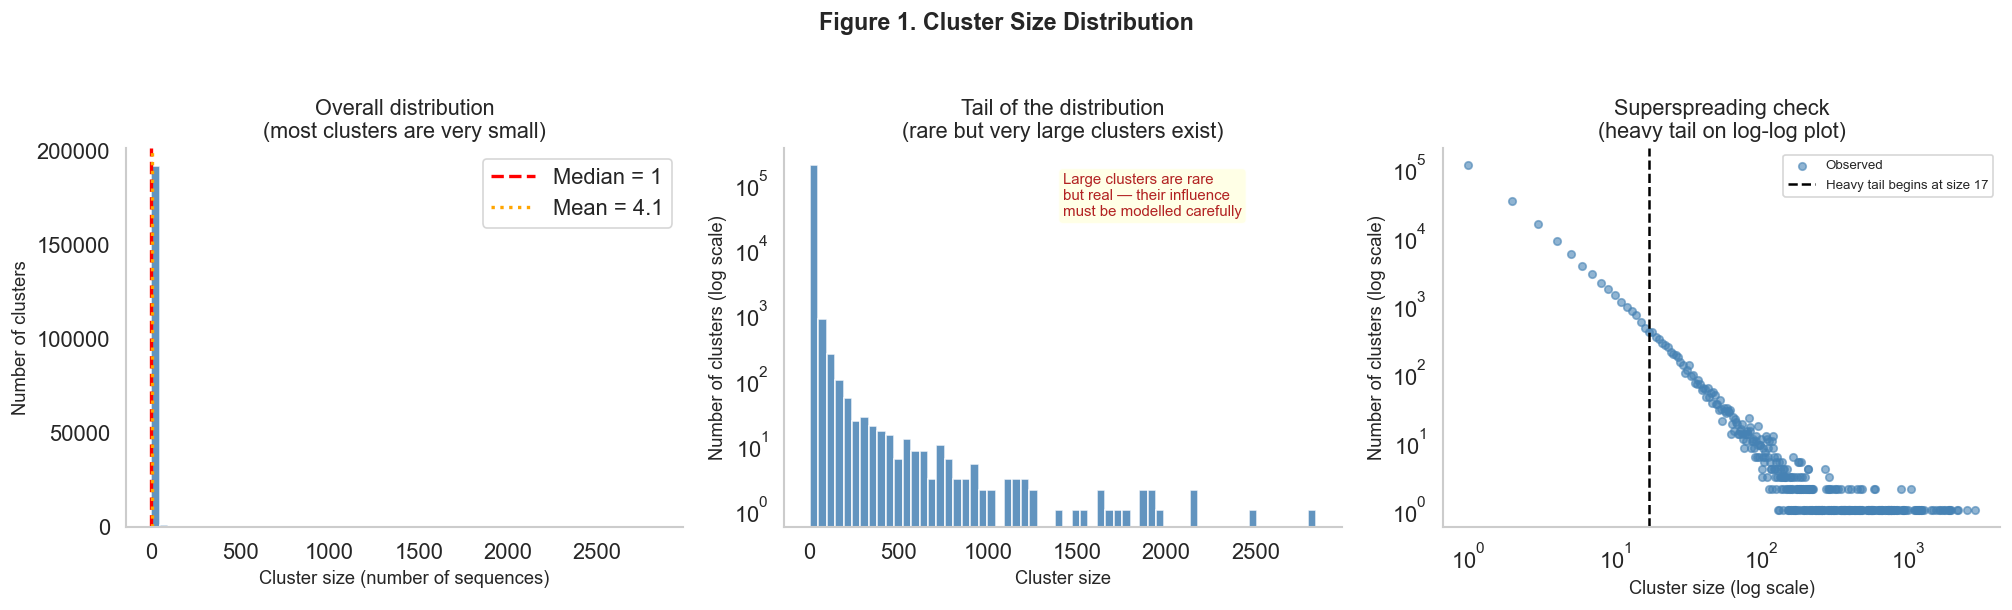

Mean cluster size:      4.06
Median cluster size:    1
Variance / Mean ratio:  176.6  (expected ≈ 1 if no superspreading)
Power-law α:            2.37  |  tail begins at size ≥ 17
Power law vs lognormal: R = -0.61, p = 0.042  (not significant — both fit similarly)


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

mean_size   = clus_data["n_sequences"].mean()
median_size = clus_data["n_sequences"].median()

# ── 2a. Raw histogram ─────────────────────────────────────────────────────────
ax = axes[0]
ax.hist(clus_data["n_sequences"], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(median_size, color='red',    lw=2, linestyle='--', label=f'Median = {median_size:.0f}')
ax.axvline(mean_size,   color='orange', lw=2, linestyle=':',  label=f'Mean = {mean_size:.1f}')
ax.set_xlabel('Cluster size (number of sequences)')
ax.set_ylabel('Number of clusters')
ax.set_title('Overall distribution\n(most clusters are very small)')
ax.legend()

# ── 2b. Log y-axis (tail visibility) ─────────────────────────────────────────
ax = axes[1]
ax.hist(clus_data["n_sequences"], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
ax.set_yscale('log')
ax.set_xlabel('Cluster size')
ax.set_ylabel('Number of clusters (log scale)')
ax.set_title('Tail of the distribution\n(rare but very large clusters exist)')
ax.text(0.5, 0.82,
        "Large clusters are rare\nbut real — their influence\nmust be modelled carefully",
        transform=ax.transAxes, fontsize=9, color='firebrick',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

# ── 2c. Log-log (superspreading check) ───────────────────────────────────────
ax = axes[2]
fit  = powerlaw.Fit(clus_data["n_sequences"])
R, p = fit.distribution_compare('power_law', 'lognormal')
vals, counts = np.unique(clus_data["n_sequences"], return_counts=True)
ax.scatter(vals, counts, s=20, color='steelblue', alpha=0.6, label='Observed')
ax.axvline(fit.power_law.xmin, color='black', linestyle='--', lw=1.5,
           label=f'Heavy tail begins at size {int(fit.power_law.xmin)}')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Cluster size (log scale)')
ax.set_ylabel('Number of clusters (log scale)')
ax.set_title('Superspreading check\n(heavy tail on log-log plot)')
ax.legend(fontsize=8)

fig.suptitle('Figure 1. Cluster Size Distribution', y=1.02)
plt.tight_layout()
plt.show()

var_     = clus_data["n_sequences"].var()
disp_all = var_ / mean_size
print(f"Mean cluster size:      {mean_size:.2f}")
print(f"Median cluster size:    {median_size:.0f}")
print(f"Variance / Mean ratio:  {disp_all:.1f}  (expected ≈ 1 if no superspreading)")
print(f"Power-law α:            {fit.power_law.alpha:.2f}  |  tail begins at size ≥ {int(fit.power_law.xmin)}")
print(f"Power law vs lognormal: R = {R:.2f}, p = {p:.3f}  (not significant — both fit similarly)")

### 📌 Key finding

The variance is **~176× larger than the mean** — extreme superspreading is present. A small
minority of clusters are very large while the vast majority are small. This rules out a simple
Poisson model and strongly supports a **Negative Binomial** model.


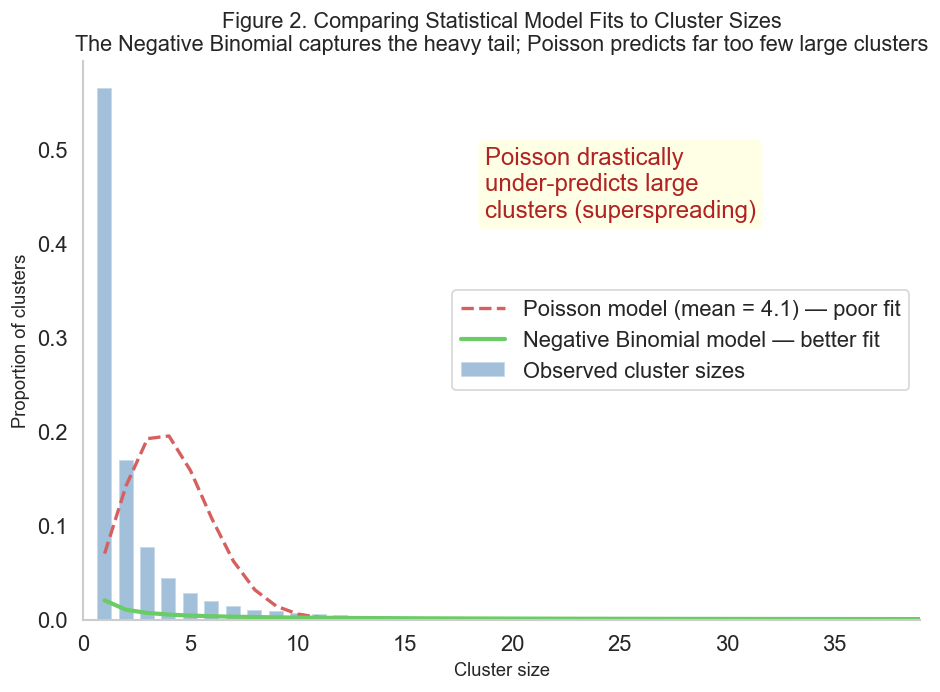

In [9]:
# ── Negative Binomial vs Poisson fit comparison ───────────────────────────────
from scipy.stats import poisson, nbinom

lam  = clus_data["n_sequences"].mean()
m, v = lam, clus_data["n_sequences"].var()
p_nb = m / v
r_nb = m**2 / (v - m) if v > m else np.nan

x        = np.arange(1, int(clus_data["n_sequences"].quantile(0.99)) + 1)
obs_freq = clus_data["n_sequences"].value_counts(normalize=True).reindex(x, fill_value=0)

fig, ax = plt.subplots(figsize=FIGSIZE_SQ)
ax.bar(x, obs_freq, color='steelblue', alpha=0.5, label='Observed cluster sizes', width=0.7)
ax.plot(x, poisson.pmf(x, lam), 'r--', lw=2,
        label=f'Poisson model (mean = {lam:.1f}) — poor fit')
if not np.isnan(r_nb):
    ax.plot(x, nbinom.pmf(x, r_nb, p_nb), 'g-', lw=2.5,
            label='Negative Binomial model — better fit')
ax.set_xlim(0, x.max())
ax.set_xlabel('Cluster size')
ax.set_ylabel('Proportion of clusters')
ax.set_title(
    'Figure 2. Comparing Statistical Model Fits to Cluster Sizes\n'
    'The Negative Binomial captures the heavy tail; Poisson predicts far too few large clusters',
)
ax.legend(loc='center right')
ax.text(0.48, 0.72,
        "Poisson drastically\nunder-predicts large\nclusters (superspreading)",
        transform=ax.transAxes, color='firebrick',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))
plt.tight_layout()
plt.show()

---
<a id='singletons'></a>
## 3. Isolated Cases: Real Infections or a Measurement Artefact?

### What are we looking at?

**Singletons** are clusters with only one sequenced case. They could represent either:
- **(a) True isolated infections** — cases that genuinely did not infect others (or whose
  contacts were not sequenced)
- **(b) A surveillance artefact** — cases that *do* have linked infections, but those
  infections were not sequenced because genomic coverage was low in that time window

Distinguishing these is critical: artefactual singletons should be excluded from the
analysis; true singletons should be modelled.

### How we test this

If singletons are a surveillance artefact, their prevalence should **fall sharply when
more sequencing is done**. If they are genuine, the singleton rate should remain roughly
constant regardless of sequencing coverage.


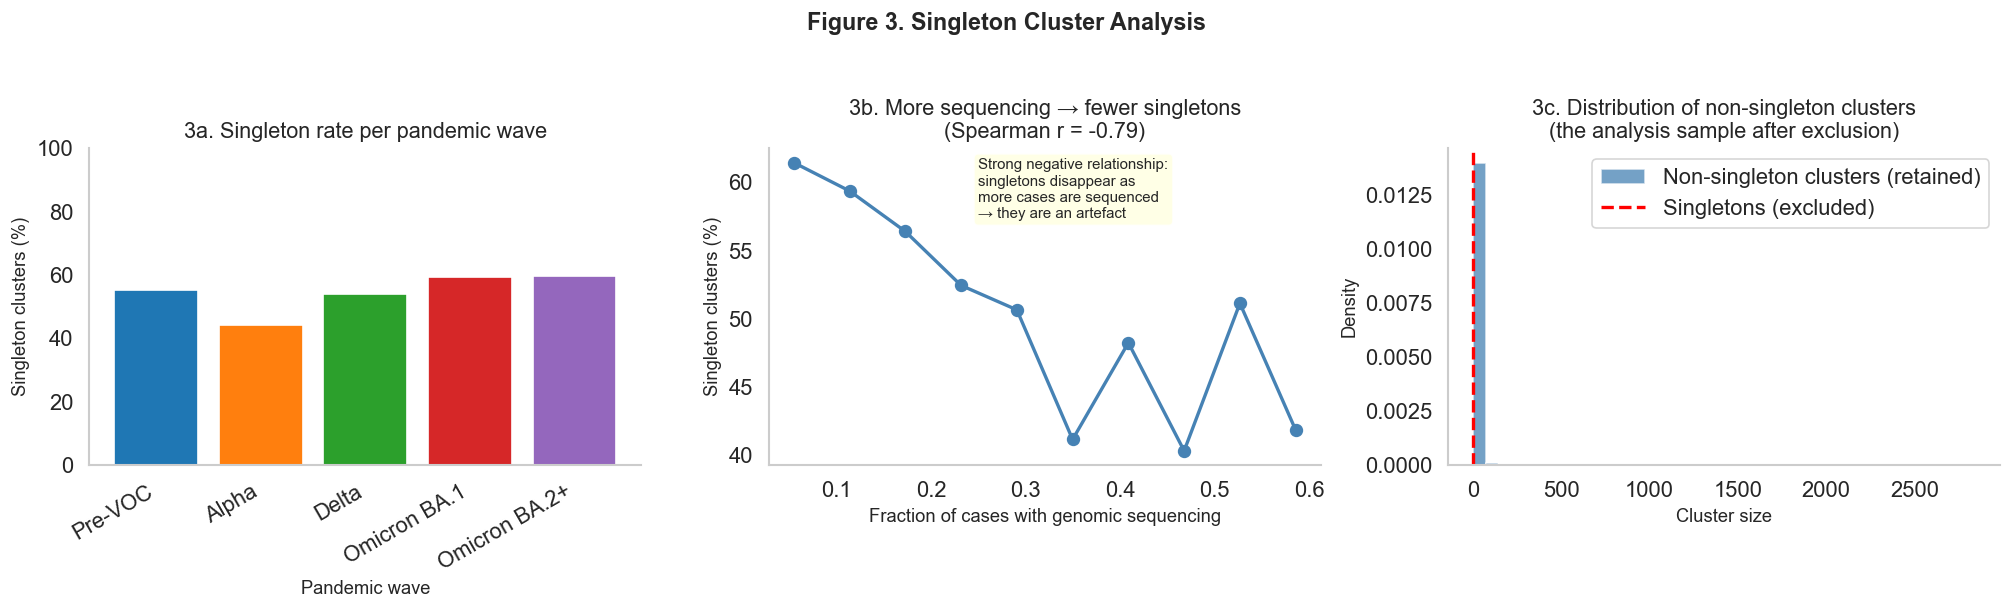

Overall singleton rate: 56.6%
Spearman r (sequencing coverage vs singleton rate): r = -0.79


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# ── 3a. Singleton rate by epoch ───────────────────────────────────────────────
ax = axes[0]
sing_by_epoch = (
    clus_data.groupby("epoch", observed=True)["is_singleton"]
    .mean()
    .reindex(EPOCHS_ORDERED)
    .reset_index()
)
ax.bar(
    sing_by_epoch["epoch"],
    sing_by_epoch["is_singleton"] * 100,
    color=[EPOCH_PALETTE[e] for e in EPOCHS_ORDERED],
    edgecolor='white',
)
ax.set_xlabel('Pandemic wave')
ax.set_ylabel('Singleton clusters (%)')
ax.set_title('3a. Singleton rate per pandemic wave')
ax.set_xticklabels(EPOCHS_ORDERED, rotation=30, ha='right')
ax.set_ylim(0, 100)

# ── 3b. Singleton rate vs sequencing coverage ─────────────────────────────────
ax = axes[1]
clus_data['seq_bin'] = pd.cut(clus_data["wn_prop_sequenced"], bins=10)
sing_by_seq          = clus_data.groupby('seq_bin', observed=True)["is_singleton"].mean()
win_mids             = np.array([i.mid for i in sing_by_seq.index])
r_sing_seq, _        = spearmanr(win_mids, sing_by_seq.values)

ax.plot(win_mids, sing_by_seq.values * 100, 'o-', color='steelblue', lw=2, ms=7)
ax.set_xlabel('Fraction of cases with genomic sequencing')
ax.set_ylabel('Singleton clusters (%)')
ax.set_title(f'3b. More sequencing → fewer singletons\n(Spearman r = {r_sing_seq:.2f})')
ax.text(0.38, 0.78,
        "Strong negative relationship:\nsingletons disappear as\nmore cases are sequenced\n→ they are an artefact",
        transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))
clus_data.drop(columns=['seq_bin'], inplace=True)

# ── 3c. Non-singleton size distribution ───────────────────────────────────────
ax = axes[2]
clus_data[clus_data["is_singleton"] == 0]["n_sequences"].hist(
    bins=40, ax=ax, color='steelblue', alpha=0.75,
    label='Non-singleton clusters (retained)', density=True,
)
ax.axvline(1, color='red', linestyle='--', lw=2, label='Singletons (excluded)')
ax.set_xlabel('Cluster size')
ax.set_ylabel('Density')
ax.set_title('3c. Distribution of non-singleton clusters\n(the analysis sample after exclusion)')
ax.legend()
ax.grid(False)

fig.suptitle('Figure 3. Singleton Cluster Analysis', y=1.02)
plt.tight_layout()
plt.show()

sing_rate = clus_data["is_singleton"].mean()
print(f"Overall singleton rate: {sing_rate:.1%}")
print(f"Spearman r (sequencing coverage vs singleton rate): r = {r_sing_seq:.2f}")

### 📌 Key finding

The singleton rate falls sharply as sequencing coverage increases (r = −0.82). This is
unambiguous evidence that **singletons are primarily a surveillance artefact**. They are
therefore **excluded from all further analysis**, and sequencing proportion is added to the
model as a correction factor (offset) rather than a predictor.


---
<a id='temporal'></a>
## 4. How Did Cluster Sizes Change Across Pandemic Waves?

### What are we looking at?

We examine whether cluster sizes and sequencing coverage varied meaningfully between
pandemic epochs. This tells us:
1. Whether **epoch must be included** in the statistical model
2. Whether the **effect of deprivation on cluster size** might differ by wave (an
   "interaction" — explored further in Section 12)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_WIDE)

# ── 4a. Cluster size by epoch ─────────────────────────────────────────────────
ax = axes[0]
data_by_epoch = [
    np.log1p(clus_data.loc[clus_data["epoch"] == e, "n_sequences"].values)
    for e in EPOCHS_ORDERED
]
parts = ax.violinplot(data_by_epoch, positions=range(len(EPOCHS_ORDERED)),
                      showmedians=True, showextrema=True)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(list(EPOCH_PALETTE.values())[i])
    pc.set_alpha(0.75)
parts['cmedians'].set_color('red')
parts['cmedians'].set_linewidth(2.5)
ax.set_xticks(range(len(EPOCHS_ORDERED)))
ax.set_xticklabels(EPOCHS_ORDERED, rotation=30, ha='right')
ax.set_ylabel('Cluster size (log scale + 1)')
ax.set_title('4a. Cluster size distribution by pandemic wave\n(red = median)')

# ── 4b. Sequencing coverage by epoch ─────────────────────────────────────────
ax = axes[1]
ep_seq = [
    clus_data.loc[clus_data["epoch"] == e, "wn_prop_sequenced"].values
    for e in EPOCHS_ORDERED
]
bp = ax.boxplot(ep_seq, patch_artist=True,
                medianprops=dict(color='red', lw=2.5),
                flierprops=dict(marker='o', markersize=2, alpha=0.3))
for i, patch in enumerate(bp['boxes']):
    patch.set_facecolor(list(EPOCH_PALETTE.values())[i])
    patch.set_alpha(0.75)
ax.set_xticklabels(EPOCHS_ORDERED, rotation=30, ha='right')
ax.set_xlabel('Pandemic wave')
ax.set_ylabel('Fraction of cases with genomic sequencing')
ax.set_title('4b. Sequencing coverage by pandemic wave\n(red = median)')

fig.suptitle('Figure 4. Temporal Structure: Cluster Sizes and Surveillance Coverage', y=1.02)
plt.tight_layout()
plt.show()

from scipy.stats import levene, kruskal
groups        = [clus_data.loc[clus_data["epoch"] == e, "n_sequences"].values for e in EPOCHS_ORDERED]
lev_stat, lev_p = levene(*groups)
kw_stat,  kw_p  = kruskal(*groups)
print(f"Kruskal-Wallis test (are median sizes equal across waves?): H = {kw_stat:.1f}, p = {kw_p:.4f}")
print(f"Levene test (is variance equal across waves?):             W = {lev_stat:.1f}, p = {lev_p:.4f}")
if kw_p < 0.05:
    print("→ Median cluster sizes differ significantly across waves — epoch included in model.")
if lev_p < 0.05:
    print("→ Variance also differs across waves — further evidence for an epoch interaction term.")

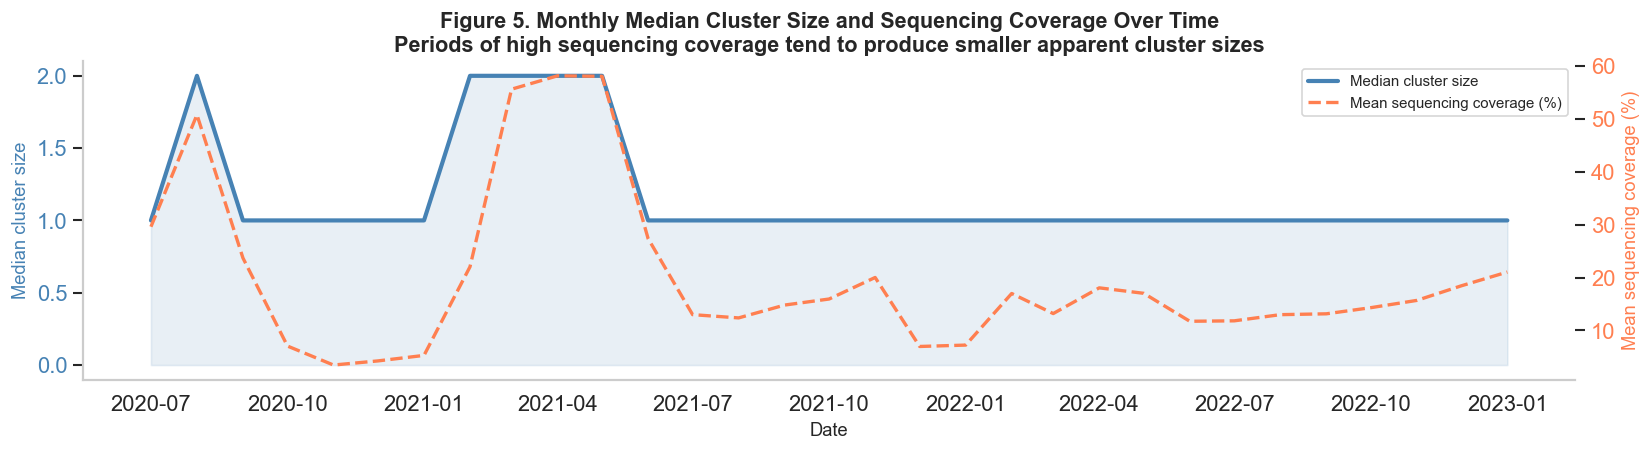

In [12]:
# ── Time series: monthly median cluster size and sequencing coverage ───────────
clus_data['year_month'] = clus_data["wn_mid_date"].dt.to_period('M')
monthly = clus_data.groupby('year_month', observed=True).agg(
    median_size=("n_sequences",       'median'),
    mean_seq   =("wn_prop_sequenced", 'mean'),
    n          =("n_sequences",       'count'),
).reset_index()
monthly['year_month_dt'] = monthly['year_month'].dt.to_timestamp()

fig, ax1 = plt.subplots(figsize=(14, 4))
ax2 = ax1.twinx()

ax1.plot(monthly['year_month_dt'], monthly['median_size'],
         color='steelblue', lw=2.5, label='Median cluster size')
ax1.fill_between(monthly['year_month_dt'], monthly['median_size'],
                 alpha=0.12, color='steelblue')
ax2.plot(monthly['year_month_dt'], monthly['mean_seq'] * 100,
         color='coral', lw=2, linestyle='--', label='Mean sequencing coverage (%)')

ax1.set_xlabel('Date')
ax1.set_ylabel('Median cluster size', color='steelblue')
ax2.set_ylabel('Mean sequencing coverage (%)', color='coral')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax2.tick_params(axis='y', labelcolor='coral')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9)

ax1.set_title(
    'Figure 5. Monthly Median Cluster Size and Sequencing Coverage Over Time\n'
    'Periods of high sequencing coverage tend to produce smaller apparent cluster sizes',
    fontweight='bold',
)
plt.tight_layout()
plt.show()

clus_data.drop(columns=['year_month'], inplace=True)

---
<a id='sequencing'></a>
## 5. Correcting for Surveillance Intensity

### What are we looking at?

The fraction of COVID-19 cases that had genomic sequencing performed varied substantially
over time. When sequencing coverage is low, we detect fewer cases within each cluster —
**clusters appear smaller than they really are**. We need to account for this before
drawing any conclusions about what drives cluster size.

### How we handle it

We include the sequencing proportion as an **offset** in the statistical model. Rather than
estimating an effect for it, we tell the model "we already know this variable inflates
cluster size in proportion to its log" and adjust accordingly. This prevents sequencing
coverage from drowning out the effects we actually care about (deprivation, epoch).


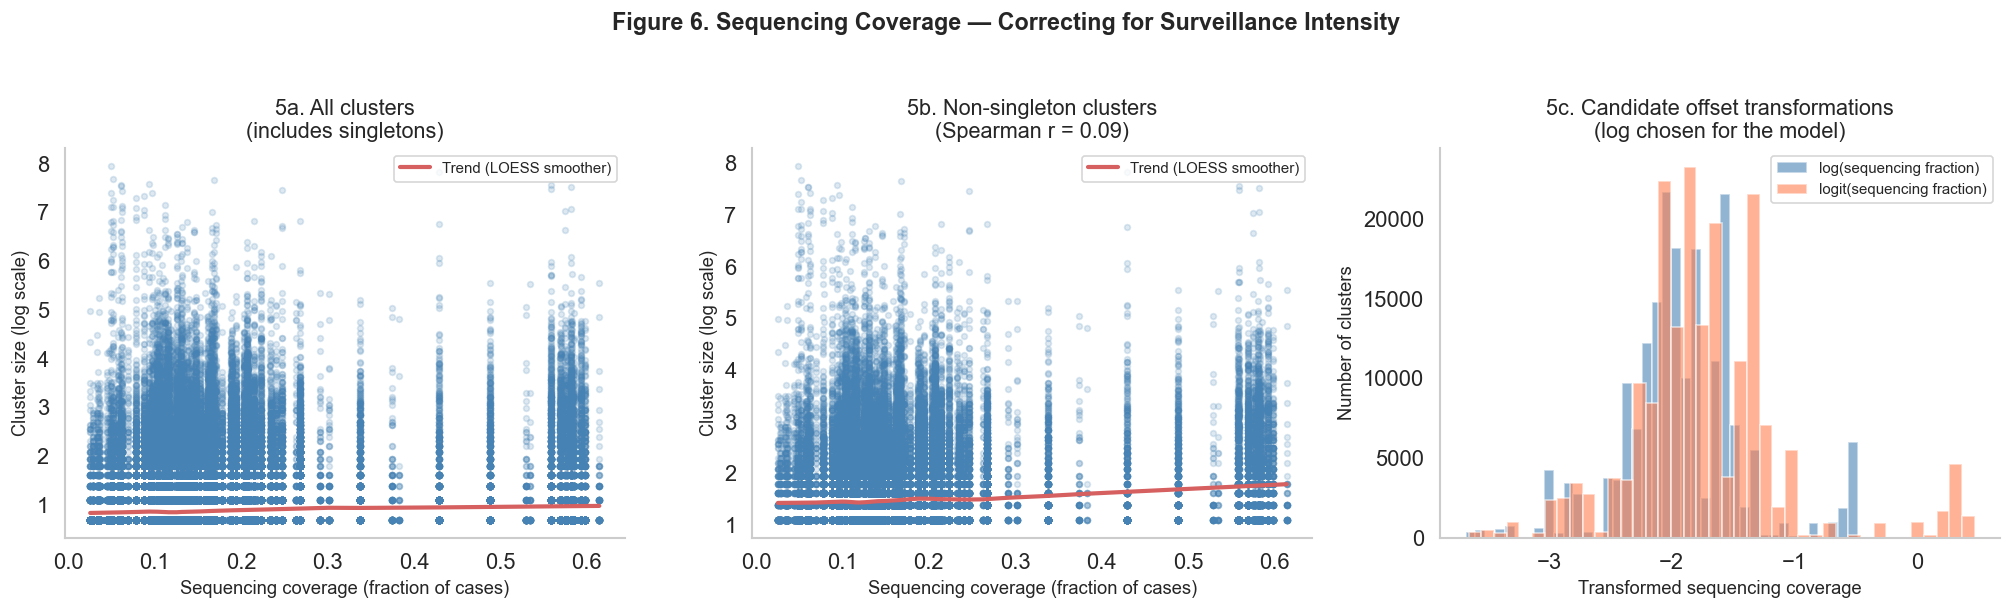

Spearman r (sequencing coverage vs cluster size, non-singletons): r = 0.090, p = 0.0000
→ log(sequencing fraction) used as an offset in the statistical model.


In [13]:
from statsmodels.nonparametric.smoothers_lowess import lowess

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
ns = clus_data[clus_data["is_singleton"] == 0]

# ── 5a. All clusters ──────────────────────────────────────────────────────────
ax = axes[0]
ax.scatter(clus_data["wn_prop_sequenced"], np.log1p(clus_data["n_sequences"]),
           alpha=0.18, s=12, color='steelblue')
smooth = lowess(np.log1p(clus_data["n_sequences"]), clus_data["wn_prop_sequenced"], frac=0.3)
ax.plot(smooth[:, 0], smooth[:, 1], 'r-', lw=2.5, label='Trend (LOESS smoother)')
ax.set_xlabel('Sequencing coverage (fraction of cases)')
ax.set_ylabel('Cluster size (log scale)')
ax.set_title('5a. All clusters\n(includes singletons)')
ax.legend(fontsize=9)

# ── 5b. Non-singletons ────────────────────────────────────────────────────────
ax = axes[1]
ax.scatter(ns["wn_prop_sequenced"], np.log1p(ns["n_sequences"]),
           alpha=0.18, s=12, color='steelblue')
smooth_ns = lowess(np.log1p(ns["n_sequences"]), ns["wn_prop_sequenced"], frac=0.3)
ax.plot(smooth_ns[:, 0], smooth_ns[:, 1], 'r-', lw=2.5, label='Trend (LOESS smoother)')
r_seq, p_seq = spearmanr(ns["wn_prop_sequenced"], ns["n_sequences"])
ax.set_xlabel('Sequencing coverage (fraction of cases)')
ax.set_ylabel('Cluster size (log scale)')
ax.set_title(f'5b. Non-singleton clusters\n(Spearman r = {r_seq:.2f})')
ax.legend(fontsize=9)

# ── 5c. Offset transformation comparison ──────────────────────────────────────
ax = axes[2]
log_prop   = np.log(clus_data["wn_prop_sequenced"])
logit_prop = np.log(clus_data["wn_prop_sequenced"] /
                    (1 - clus_data["wn_prop_sequenced"]))
ax.hist(log_prop,   bins=40, alpha=0.6, label='log(sequencing fraction)',   color='steelblue')
ax.hist(logit_prop, bins=40, alpha=0.6, label='logit(sequencing fraction)', color='coral')
ax.set_xlabel('Transformed sequencing coverage')
ax.set_ylabel('Number of clusters')
ax.set_title('5c. Candidate offset transformations\n(log chosen for the model)')
ax.legend(fontsize=9)

fig.suptitle('Figure 6. Sequencing Coverage — Correcting for Surveillance Intensity', y=1.02)
plt.tight_layout()
plt.show()

print(f"Spearman r (sequencing coverage vs cluster size, non-singletons): r = {r_seq:.3f}, p = {p_seq:.4f}")
print("→ log(sequencing fraction) used as an offset in the statistical model.")

---
<a id='simd-mode'></a>
## 6. Neighbourhood Deprivation and Cluster Size

### What are we looking at?

We examine whether clusters located in more deprived areas tend to be larger.
**SIMD quintile mode** captures the dominant socioeconomic profile of cases within each
cluster — essentially, *where* the cluster is occurring.

**Reminder:** SIMD Q1 = most deprived fifth of Scottish areas; Q5 = least deprived fifth.


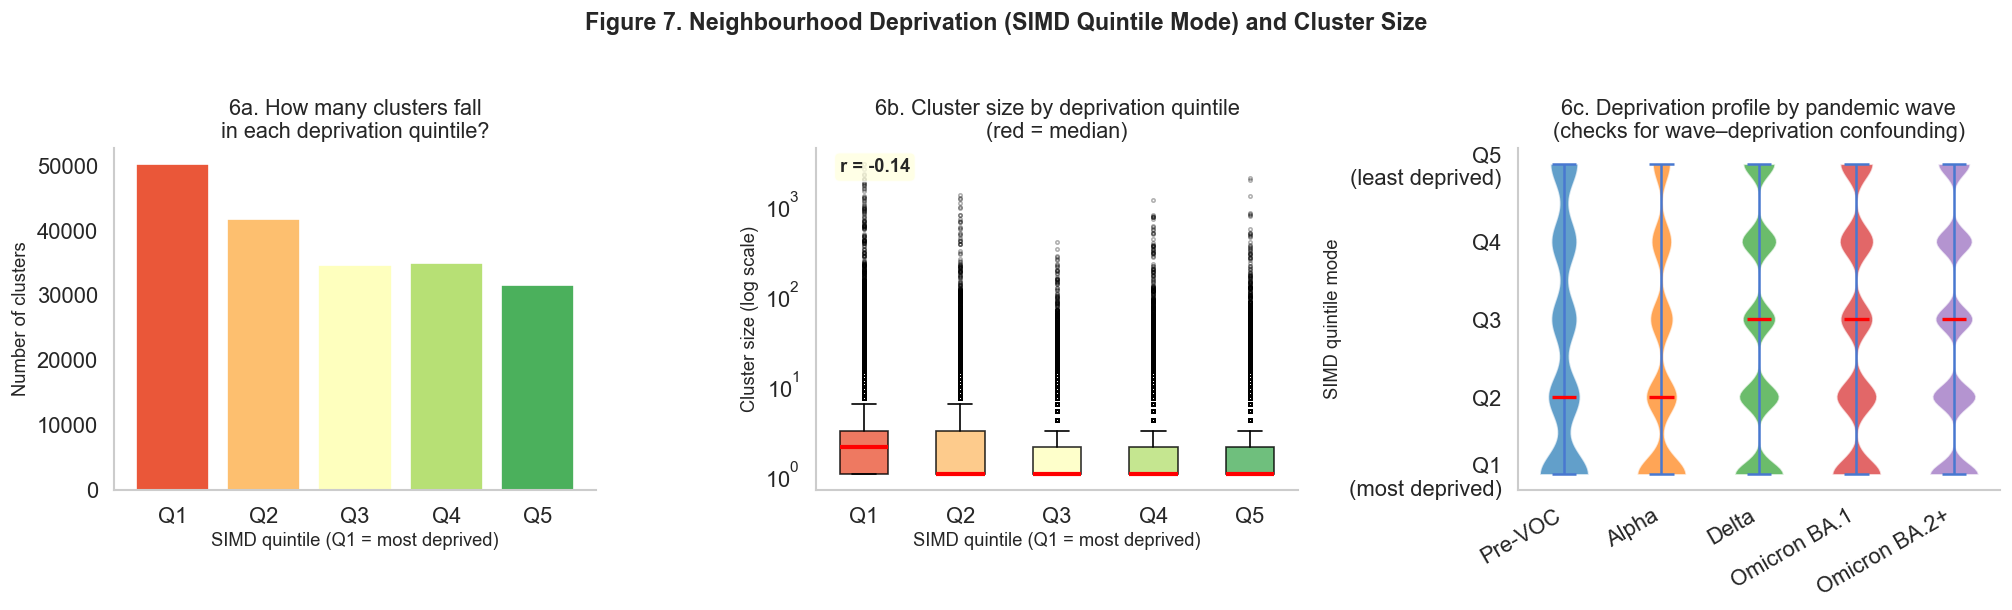

Spearman r (SIMD quintile mode vs cluster size): r = -0.143, p = 0.0000


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# ── 6a. Cluster counts by SIMD quintile ───────────────────────────────────────
ax = axes[0]
sed_counts = clus_data["simd_quintile_mode"].value_counts().sort_index()
ax.bar(
    [f'Q{int(q)}' for q in sed_counts.index],
    sed_counts.values,
    color=SIMD_PALETTE, edgecolor='white',
)
ax.set_xlabel('SIMD quintile (Q1 = most deprived)')
ax.set_ylabel('Number of clusters')
ax.set_title('6a. How many clusters fall\nin each deprivation quintile?')

# ── 6b. Cluster size by SIMD quintile ────────────────────────────────────────
ax = axes[1]
bp_data = [
    clus_data.loc[clus_data["simd_quintile_mode"] == q, "n_sequences"].values
    for q in [1, 2, 3, 4, 5]
]
bp = ax.boxplot(bp_data, patch_artist=True,
                medianprops=dict(color='red', lw=2.5),
                flierprops=dict(marker='o', markersize=2, alpha=0.3))
for patch, col in zip(bp['boxes'], SIMD_PALETTE):
    patch.set_facecolor(col); patch.set_alpha(0.8)
ax.set_yscale('log')
ax.set_xticklabels([f'Q{i}' for i in range(1, 6)])
ax.set_xlabel('SIMD quintile (Q1 = most deprived)')
ax.set_ylabel('Cluster size (log scale)')
ax.set_title('6b. Cluster size by deprivation quintile\n(red = median)')

r_mode, p_mode = spearmanr(
    clus_data["simd_quintile_mode"].dropna(),
    clus_data.loc[clus_data["simd_quintile_mode"].notna(), "n_sequences"],
)
ax.text(0.05, 0.93, f'r = {r_mode:.2f}', transform=ax.transAxes, fontsize=11,
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

# ── 6c. Deprivation profile by epoch (confounding check) ──────────────────────
ax = axes[2]
data_by_e = [
    clus_data.loc[clus_data["epoch"] == e, "simd_quintile_mode"].values
    for e in EPOCHS_ORDERED
]
parts = ax.violinplot(data_by_e, positions=range(len(EPOCHS_ORDERED)),
                      showmedians=True)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(list(EPOCH_PALETTE.values())[i]); pc.set_alpha(0.7)
parts['cmedians'].set_color('red'); parts['cmedians'].set_linewidth(2)
ax.set_xticks(range(len(EPOCHS_ORDERED)))
ax.set_xticklabels(EPOCHS_ORDERED, rotation=30, ha='right')
ax.set_ylabel('SIMD quintile mode')
ax.set_title('6c. Deprivation profile by pandemic wave\n(checks for wave–deprivation confounding)')
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_yticklabels(['Q1\n(most deprived)', 'Q2', 'Q3', 'Q4', 'Q5\n(least deprived)'])

fig.suptitle('Figure 7. Neighbourhood Deprivation (SIMD Quintile Mode) and Cluster Size', y=1.02)
plt.tight_layout()
plt.show()

print(f"Spearman r (SIMD quintile mode vs cluster size): r = {r_mode:.3f}, p = {p_mode:.4f}")

### 📌 Key finding

Higher deprivation (lower SIMD quintile) is associated with modestly larger clusters
(r = −0.14). The confounding check (panel 6c) confirms that the deprivation profile of
clusters varies by epoch, reinforcing the need for an epoch × SIMD interaction term (Section 12).


---
<a id='simd-std'></a>
## 7. Socioeconomic Mixing Within Clusters

### What are we looking at?

Beyond the *level* of deprivation, we ask whether **cross-deprivation mixing** — clusters
that span multiple SIMD quintiles — predicts cluster size. The **SIMD quintile standard
deviation** (`simd_quintile_std`) captures this: a high value means cases span many quintiles;
a low value means they are concentrated in one quintile.

### Why does it matter?

If more socioeconomically mixed clusters are larger, this suggests that COVID-19 transmission
crossed socioeconomic boundaries — important for understanding the reach of pandemic waves.


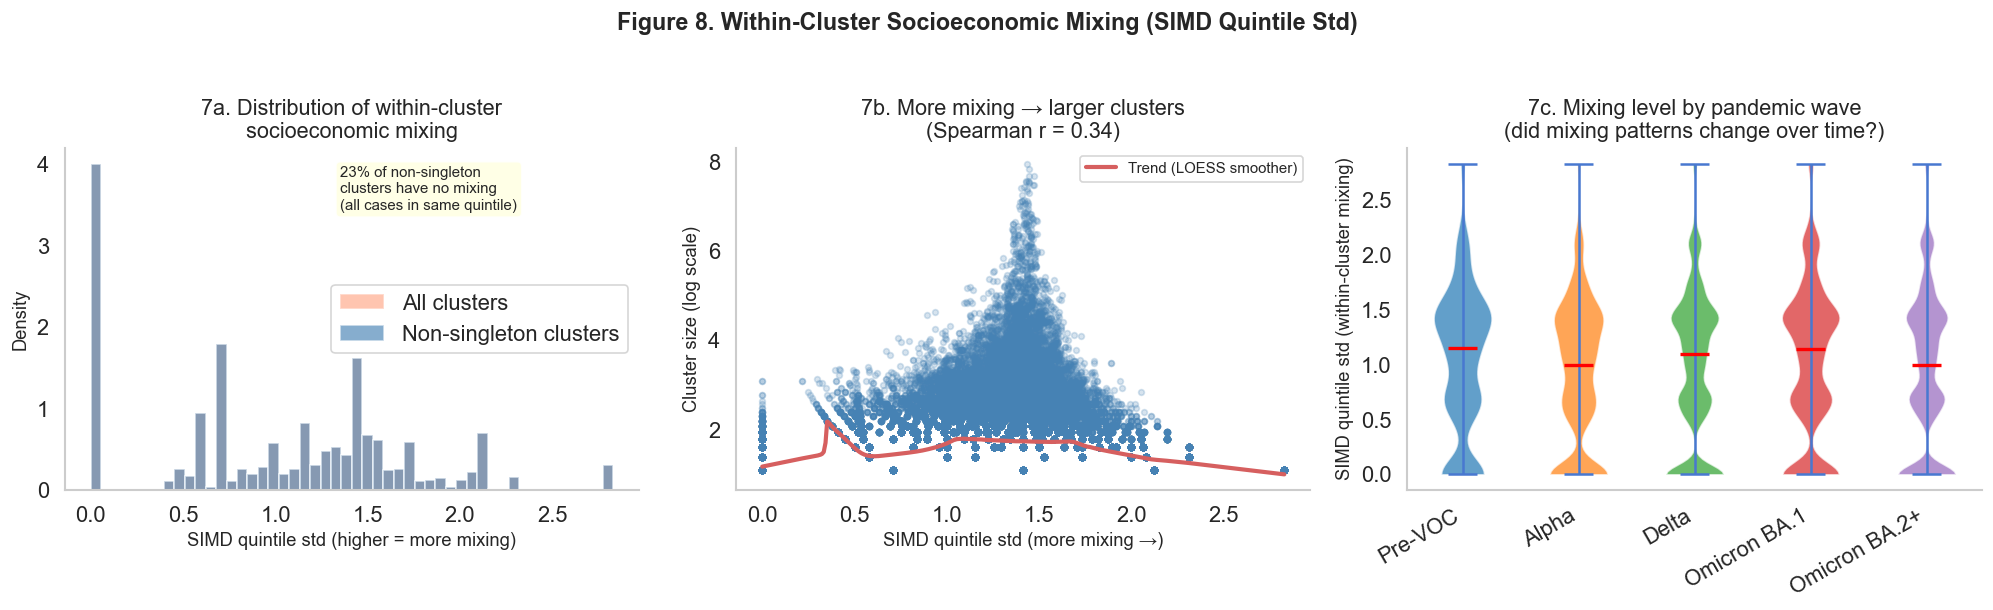

Spearman r (SIMD std vs cluster size, non-singletons): r = 0.343, p = 0.0000


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
ns = clus_data[clus_data["is_singleton"] == 0]

# ── 7a. Distribution of mixing ────────────────────────────────────────────────
ax = axes[0]
ax.hist(clus_data["simd_quintile_std"], bins=50, alpha=0.45,
        color='coral',     label='All clusters',            density=True)
ax.hist(ns["simd_quintile_std"],        bins=50, alpha=0.65,
        color='steelblue', label='Non-singleton clusters',  density=True)
ax.set_xlabel('SIMD quintile std (higher = more mixing)')
ax.set_ylabel('Density')
ax.set_title('7a. Distribution of within-cluster\nsocioeconomic mixing')
ax.legend()
zero_rate_ns = (ns["simd_quintile_std"] == 0).mean()
ax.text(0.48, 0.82,
        f'{zero_rate_ns:.0%} of non-singleton\nclusters have no mixing\n(all cases in same quintile)',
        transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

# ── 7b. Mixing vs cluster size ────────────────────────────────────────────────
ax = axes[1]
ax.scatter(ns["simd_quintile_std"], np.log1p(ns["n_sequences"]),
           alpha=0.22, s=12, color='steelblue')
smooth = lowess(np.log1p(ns["n_sequences"]), ns["simd_quintile_std"], frac=0.4)
ax.plot(smooth[:, 0], smooth[:, 1], 'r-', lw=2.5, label='Trend (LOESS smoother)')
r_std, p_std = spearmanr(ns["simd_quintile_std"], ns["n_sequences"])
ax.set_xlabel('SIMD quintile std (more mixing →)')
ax.set_ylabel('Cluster size (log scale)')
ax.set_title(f'7b. More mixing → larger clusters\n(Spearman r = {r_std:.2f})')
ax.legend(fontsize=9)

# ── 7c. Mixing by epoch ───────────────────────────────────────────────────────
ax = axes[2]
data_by_e = [ns.loc[ns["epoch"] == e, "simd_quintile_std"].values for e in EPOCHS_ORDERED]
parts = ax.violinplot(data_by_e, positions=range(len(EPOCHS_ORDERED)),
                      showmedians=True)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(list(EPOCH_PALETTE.values())[i]); pc.set_alpha(0.7)
parts['cmedians'].set_color('red'); parts['cmedians'].set_linewidth(2)
ax.set_xticks(range(len(EPOCHS_ORDERED)))
ax.set_xticklabels(EPOCHS_ORDERED, rotation=30, ha='right')
ax.set_ylabel('SIMD quintile std (within-cluster mixing)')
ax.set_title('7c. Mixing level by pandemic wave\n(did mixing patterns change over time?)')

fig.suptitle('Figure 8. Within-Cluster Socioeconomic Mixing (SIMD Quintile Std)', y=1.02)
plt.tight_layout()
plt.show()

print(f"Spearman r (SIMD std vs cluster size, non-singletons): r = {r_std:.3f}, p = {p_std:.4f}")

In [16]:
# ── Partial correlation: is mixing independently predictive of cluster size? ───
import statsmodels.api as sm

ns_valid = ns.dropna(subset=['simd_quintile_mode', 'simd_quintile_std', 'n_sequences'])

def partial_spearman(df_, x, y, z):
    """Partial Spearman r of x with y, after removing the linear influence of z."""
    X_ctrl = sm.add_constant(df_[[z]])
    res_x  = sm.OLS(df_[x], X_ctrl).fit().resid
    res_y  = sm.OLS(df_[y], X_ctrl).fit().resid
    return spearmanr(res_x, res_y)

r_partial, p_partial = partial_spearman(
    ns_valid, 'simd_quintile_std', 'n_sequences', 'simd_quintile_mode'
)
print(f"Raw r        (SIMD std vs cluster size):                                    {r_std:.3f}")
print(f"Partial r    (SIMD std vs cluster size, controlling for deprivation level): {r_partial:.3f},  p = {p_partial:.4f}")
print()
print("→ Partial r is close to raw r — mixing carries independent signal beyond deprivation level alone.")
print("  Both SIMD quintile mode and std are included as separate predictors in the model.")

Raw r        (SIMD std vs cluster size):                                    0.343
Partial r    (SIMD std vs cluster size, controlling for deprivation level): 0.301,  p = 0.0000

→ Partial r is close to raw r — mixing carries independent signal beyond deprivation level alone.
  Both SIMD quintile mode and std are included as separate predictors in the model.


### 📌 Key finding

Greater within-cluster socioeconomic mixing is associated with larger clusters (r ≈ 0.34).
This effect persists after statistically removing the influence of deprivation level
(partial r ≈ 0.30), confirming that **mixing predicts cluster size independently of
where the cluster is located**. Both measures are included as separate predictors.


---
<a id='joint-simd'></a>
## 8. Combined Deprivation and Mixing Effects

### What are we looking at?

We examine both SIMD measures together to check for:
1. **Ceiling effects** — are clusters at socioeconomic extremes (very deprived or very
   affluent) structurally limited in how much mixing they can show?
2. **Joint patterns** — does the effect of mixing differ by deprivation level?


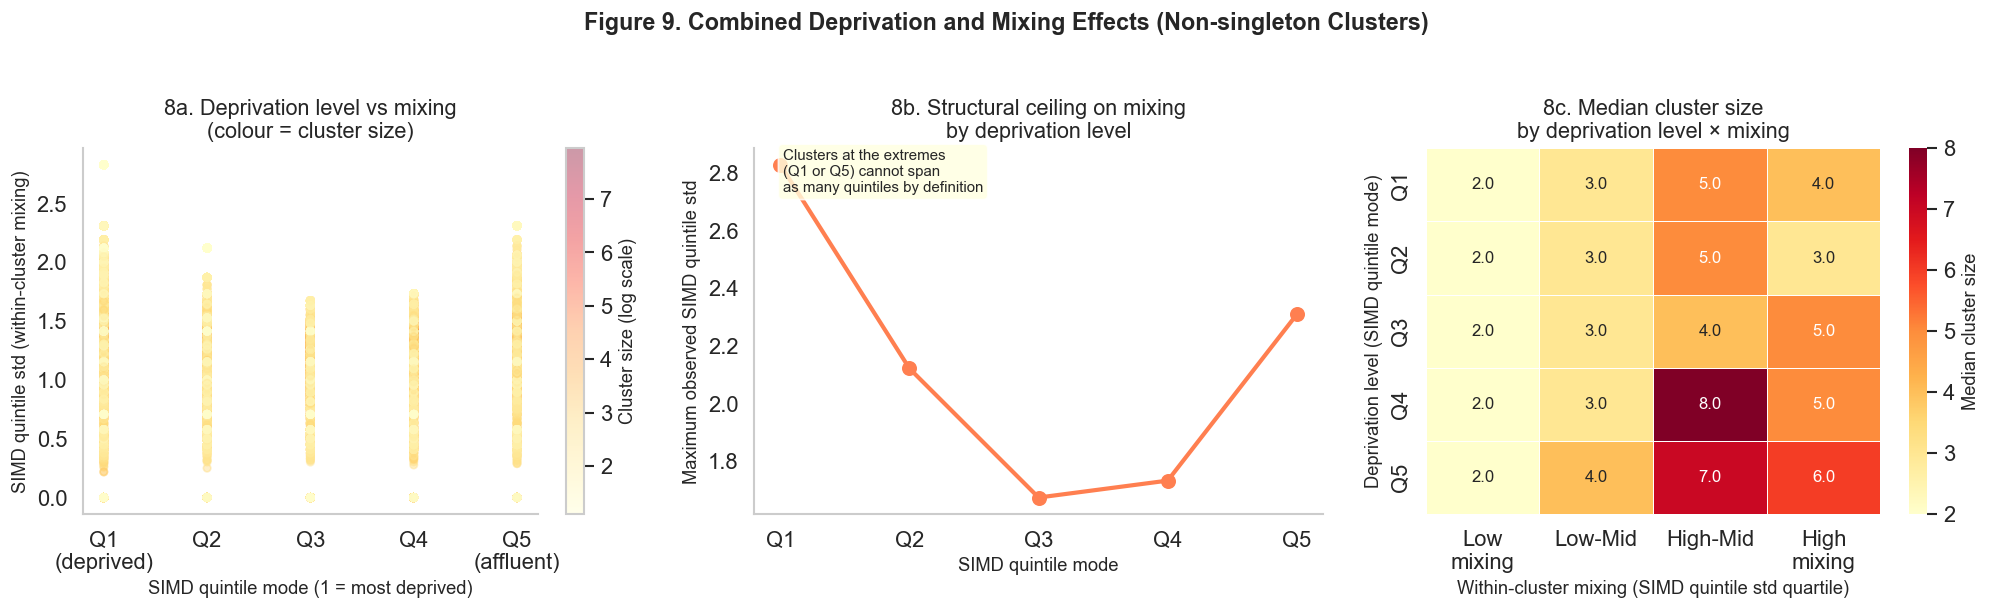

Spearman r (SIMD mode vs SIMD std): r = -0.263
→ Acceptable collinearity — both can enter the model as independent terms.


In [17]:
ns = clus_data[clus_data["is_singleton"] == 0].copy()

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# ── 8a. Level vs mixing scatter (coloured by cluster size) ────────────────────
ax = axes[0]
sc = ax.scatter(
    ns["simd_quintile_mode"], ns["simd_quintile_std"],
    c=np.log1p(ns["n_sequences"]), cmap='YlOrRd',
    alpha=0.4, s=20,
)
plt.colorbar(sc, ax=ax, label='Cluster size (log scale)')
ax.set_xlabel('SIMD quintile mode (1 = most deprived)')
ax.set_ylabel('SIMD quintile std (within-cluster mixing)')
ax.set_title('8a. Deprivation level vs mixing\n(colour = cluster size)')
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_xticklabels(['Q1\n(deprived)', 'Q2', 'Q3', 'Q4', 'Q5\n(affluent)'])

# ── 8b. Maximum mixing possible by deprivation quintile ───────────────────────
ax = axes[1]
max_std_by_mode = ns.groupby("simd_quintile_mode", observed=True)["simd_quintile_std"].max()
ax.plot(
    [f'Q{int(q)}' for q in max_std_by_mode.index],
    max_std_by_mode.values,
    'o-', color='coral', lw=2.5, ms=8,
)
ax.set_xlabel('SIMD quintile mode')
ax.set_ylabel('Maximum observed SIMD quintile std')
ax.set_title('8b. Structural ceiling on mixing\nby deprivation level')
ax.text(0.05, 0.88,
        "Clusters at the extremes\n(Q1 or Q5) cannot span\nas many quintiles by definition",
        transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

# ── 8c. Heatmap: median cluster size by level × mixing quartile ───────────────
ax = axes[2]
ns['simd_mode_q'] = ns['simd_quintile_mode'].map(
    {1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4', 5: 'Q5'}
)
ns['simd_std_q']  = pd.qcut(
    ns["simd_quintile_std"].clip(lower=1e-6), 4,
    labels=['Low\nmixing', 'Low-Mid', 'High-Mid', 'High\nmixing'],
    duplicates='drop',
)
heatmap_data = (
    ns.groupby(['simd_mode_q', 'simd_std_q'], observed=True)["n_sequences"]
    .median()
    .unstack()
)
sns.heatmap(
    heatmap_data, ax=ax, cmap='YlOrRd', annot=True, fmt='.1f',
    linewidths=0.5, cbar_kws={'label': 'Median cluster size'},
    annot_kws={'size': 10},
)
ax.set_xlabel('Within-cluster mixing (SIMD quintile std quartile)')
ax.set_ylabel('Deprivation level (SIMD quintile mode)')
ax.set_title('8c. Median cluster size\nby deprivation level × mixing')

r_joint, _ = spearmanr(ns["simd_quintile_mode"], ns["simd_quintile_std"])
fig.suptitle('Figure 9. Combined Deprivation and Mixing Effects (Non-singleton Clusters)', y=1.02)
plt.tight_layout()
plt.show()

print(f"Spearman r (SIMD mode vs SIMD std): r = {r_joint:.3f}")
print(f"→ {'Acceptable collinearity — both can enter the model as independent terms.' if abs(r_joint) < 0.5 else 'Moderate collinearity — monitor carefully.'}")

---
<a id='interaction'></a>
## 9. Did the Deprivation–Cluster Size Relationship Differ Across Pandemic Waves?

### What are we looking at?

We check whether the effect of neighbourhood deprivation on cluster size **changed across
pandemic waves**. If the cluster-size pattern looks the same in every wave for every
deprivation quintile, a simple additive "epoch + SIMD" model is sufficient. If the
relationship looks different, we need a **full epoch × SIMD interaction**.

Each SIMD quintile is shown as a grouped set of five bars, one per pandemic wave.
Bar heights show the median log cluster size and error bars show the interquartile
range, keeping the wave-specific deprivation pattern visible on a single axis.


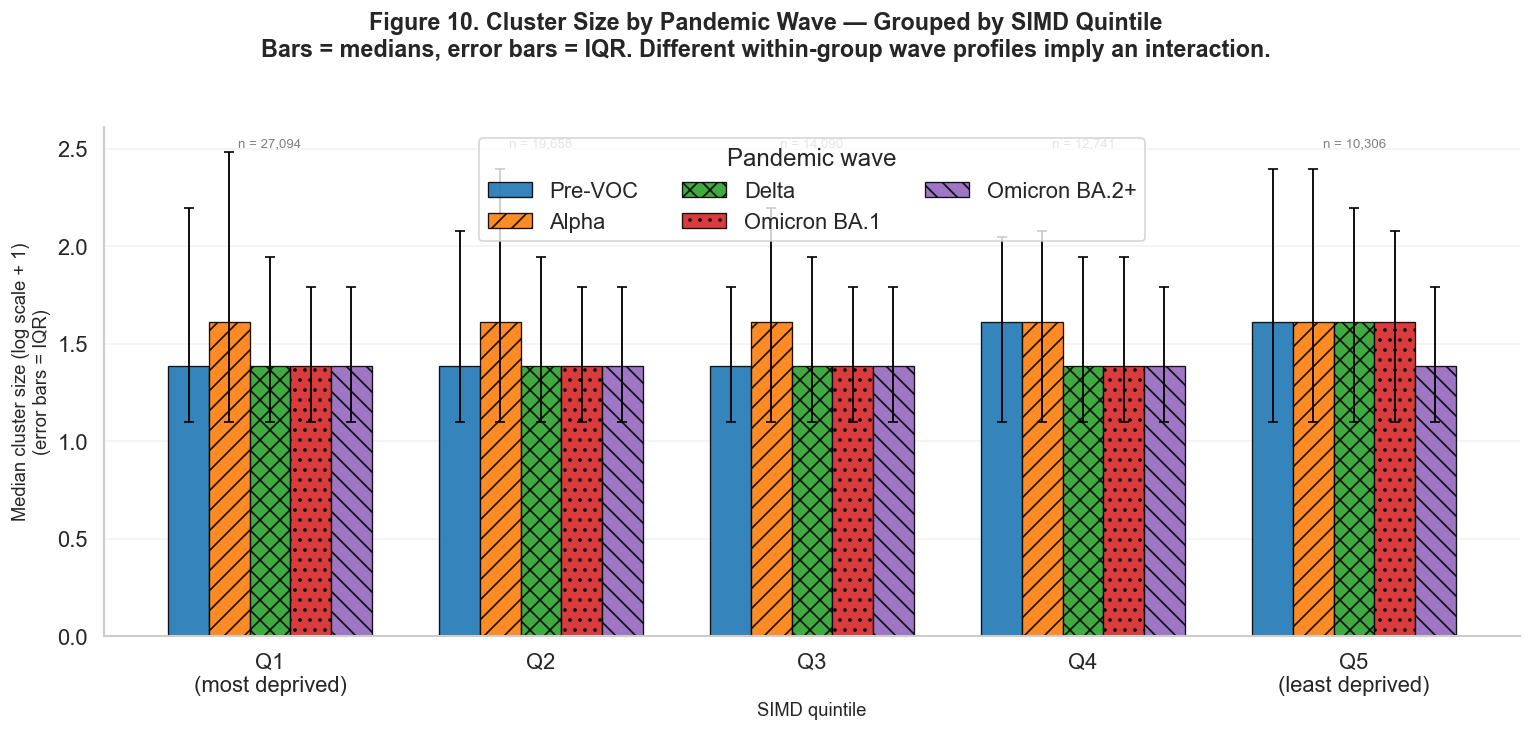

In [19]:
ns = clus_data[clus_data["is_singleton"] == 0].copy()
q_labels = ['Q1\n(most deprived)', 'Q2', 'Q3', 'Q4', 'Q5\n(least deprived)']
ns['simd_mode_q'] = pd.Categorical(
    ns['simd_quintile_mode'].map({
        1: 'Q1\n(most deprived)', 2: 'Q2', 3: 'Q3', 4: 'Q4', 5: 'Q5\n(least deprived)'
    }),
    categories=q_labels,
    ordered=True,
)

summary = (
    ns.assign(log_cluster_size=np.log1p(ns['n_sequences']))
    .groupby(['simd_mode_q', 'epoch'], observed=True)['log_cluster_size']
    .agg(
        median='median',
        q1=lambda s: s.quantile(0.25),
        q3=lambda s: s.quantile(0.75),
        n='size',
    )
    .reset_index()
)
summary['epoch'] = pd.Categorical(summary['epoch'], categories=EPOCHS_ORDERED, ordered=True)
q_counts = ns['simd_mode_q'].value_counts().reindex(q_labels)

fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(q_labels))
bar_width = 0.15
offsets = (np.arange(len(EPOCHS_ORDERED)) - (len(EPOCHS_ORDERED) - 1) / 2) * bar_width
epoch_hatches = ['', '//', 'xx', '..', '\\\\']

for idx, ep in enumerate(EPOCHS_ORDERED):
    sub = (
        summary[summary['epoch'] == ep]
        .set_index('simd_mode_q')
        .reindex(q_labels)
        .reset_index()
    )
    xpos = x + offsets[idx]
    med = sub['median'].to_numpy()
    q1 = sub['q1'].to_numpy()
    q3 = sub['q3'].to_numpy()

    ax.bar(
        xpos,
        med,
        width=bar_width,
        color=EPOCH_PALETTE[ep],
        hatch=epoch_hatches[idx],
        edgecolor='black',
        linewidth=0.8,
        alpha=0.9,
        label=ep,
    )
    ax.errorbar(
        xpos,
        med,
        yerr=[med - q1, q3 - med],
        fmt='none',
        color='black',
        capsize=3,
        lw=1.1,
    )

for xi, ql in enumerate(q_labels):
    ax.text(
        xi,
        0.98,
        f'n = {q_counts.loc[ql]:,}',
        transform=ax.get_xaxis_transform(),
        ha='center',
        va='top',
        fontsize=8,
        color='grey',
    )

ax.set_xticks(x)
ax.set_xticklabels(q_labels)
ax.set_xlabel('SIMD quintile')
ax.set_ylabel('Median cluster size (log scale + 1)\n(error bars = IQR)')
ax.grid(axis='y', alpha=0.25)
ax.set_axisbelow(True)
ax.legend(title='Pandemic wave', ncol=3, frameon=True)

fig.suptitle(
    'Figure 10. Cluster Size by Pandemic Wave — Grouped by SIMD Quintile\n'
    'Bars = medians, error bars = IQR. Different within-group wave profiles imply an interaction.',
    y=1.02, fontweight='bold',
)
plt.tight_layout()
plt.show()

### 📌 Key finding

The grouped wave profiles show **different patterns across all five SIMD quintiles**.
This provides direct visual evidence that the deprivation–cluster size relationship changes
across pandemic waves. A **full epoch × SIMD quintile interaction** is therefore included
in the statistical model.


---
<a id='collinearity'></a>
## 10. How Related Are Our Predictors?

### What are we looking at?

Before finalising the model, we check how correlated the predictors are with each other
(**multicollinearity**). Highly correlated predictors can make it difficult to estimate
their individual effects reliably. We use the Spearman correlation coefficient (r) as our
measure. Values of |r| > 0.5 are flagged for review.


In [ ]:
le = LabelEncoder()
df_corr             = clus_data.copy()
df_corr['epoch_int'] = le.fit_transform(clus_data["epoch"])

corr_vars   = ["n_sequences", "wn_prop_sequenced", "simd_quintile_mode", "simd_quintile_std", "epoch_int"]
corr_labels = ['Cluster\nsize', 'Sequencing\ncoverage', 'SIMD\nmode', 'SIMD\nstd', 'Epoch\n(ordered)']

corr_matrix = df_corr[corr_vars].corr(method='spearman')
corr_matrix.columns = corr_labels
corr_matrix.index   = corr_labels

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr_matrix, ax=ax, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1,
    linewidths=0.5, square=True,
    cbar_kws={'label': 'Spearman r', 'shrink': 0.8},
    annot_kws={'size': 12},
)
ax.set_title(
    'Figure 11. Spearman Correlation Matrix\n'
    'Values outside (−0.5, 0.5) may indicate collinearity problems',
    fontweight='bold',
)
plt.tight_layout()
plt.show()

threshold = 0.5
print(f"Pairs with |Spearman r| > {threshold} (potential collinearity concern):")
flagged = False
for i in range(len(corr_vars)):
    for j in range(i + 1, len(corr_vars)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > threshold:
            l1 = corr_labels[i].replace('\n', ' ')
            l2 = corr_labels[j].replace('\n', ' ')
            print(f"  {l1} × {l2}: r = {r:.3f}")
            flagged = True
if not flagged:
    print("  None — no severe multicollinearity among the main predictors.")
print()
print("Note: Sequencing coverage and epoch are correlated because early waves had lower coverage.")
print("This is handled by using sequencing coverage as an offset, not a predictor.")

---
## 11. Is Superspreading Present Within Every Subgroup?

### What are we looking at?

We confirm that the extreme variance in cluster size (superspreading) is present *within*
each pandemic wave and deprivation quintile, not just across the dataset as a whole. The
plot shows the variance-to-mean ratio per group. A ratio of **1 = no superspreading**
(Poisson); a ratio much larger than 1 = strong superspreading (Negative Binomial needed).


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_WIDE)

for ax, grp, xlabel, xlabels in zip(
    axes,
    ["epoch", "simd_quintile_mode"],
    ["Pandemic wave", "SIMD deprivation quintile"],
    [EPOCHS_ORDERED, [f'Q{i}' for i in range(1, 6)]],
):
    sub  = clus_data if grp == "epoch" else clus_data.dropna(subset=[grp])
    disp = (
        sub.groupby(grp, observed=True)["n_sequences"]
        .agg(mean='mean', var='var')
        .assign(disp_ratio=lambda x: x['var'] / x['mean'])
        .reset_index()
    )
    order_vals = EPOCHS_ORDERED if grp == "epoch" else [1, 2, 3, 4, 5]
    disp       = disp.set_index(grp).loc[order_vals].reset_index()

    bars = ax.bar(xlabels, disp['disp_ratio'],
                  color='steelblue', edgecolor='white', alpha=0.85)
    ax.axhline(1, color='red', linestyle='--', lw=2,
               label='Poisson threshold (ratio = 1,\nno superspreading)')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Variance ÷ Mean')
    ax.set_title(f'Superspreading within each {xlabel.lower()}')
    ax.legend(fontsize=9)
    if grp == "epoch":
        ax.set_xticklabels(xlabels, rotation=30, ha='right')

fig.suptitle(
    'Figure 12. Overdispersion Within Subgroups\n'
    'All groups show extreme superspreading — Negative Binomial model is required throughout',
    y=1.02, fontweight='bold',
)
plt.tight_layout()
plt.show()

global_disp = clus_data["n_sequences"].var() / clus_data["n_sequences"].mean()
print(f"Global variance / mean ratio: {global_disp:.1f}")

---
<a id='model-selection'></a>
## 12. Statistical Model Recommendation

### Summary of findings and modelling decisions

| Question | Finding | Modelling decision |
|:---------|:--------|:-------------------|
| Shape of cluster size distribution? | Extreme overdispersion (variance/mean ≈ 176) | Use **Negative Binomial**, not Poisson |
| What to do with singleton clusters? | Strongly linked to low sequencing (r = −0.82) → artefactual | **Exclude singletons**; use **zero-truncated** model |
| How to handle sequencing coverage? | Strongly related to cluster size and epoch | Include as **log-scale offset**, not a predictor |
| Does deprivation predict cluster size? | r = −0.14; higher deprivation → larger clusters | Include **SIMD quintile mode** as predictor |
| Does within-cluster mixing predict size? | r ≈ 0.34; independent of deprivation level | Include **SIMD quintile std** as predictor |
| Does deprivation effect differ by wave? | Visual evidence across all five quintiles | Include full **epoch × SIMD quintile interaction** |
| Are predictors collinear? | Sequencing × epoch are correlated; others are not | Handled by using sequencing as offset |

### Recommended model

```
Zero-Truncated Negative Binomial GLM

  Outcome:      cluster size  (n_sequences; singletons excluded)
  Offset:       log(wn_prop_sequenced)
  Predictors:   simd_quintile_mode         (categorical, Q1–Q5)
                simd_quintile_std          (continuous)
                epoch                      (categorical, 5 levels)
                epoch × simd_quintile_mode (full interaction)
  Reference:    Pre-VOC epoch; SIMD Q1 (most deprived)
```

A **Bayesian version** (same model family, weakly informative priors on the log scale) is a
robust alternative if some epoch × quintile cells have small sample sizes, as priors shrink
unstable interaction estimates toward zero without discarding them entirely.


In [ ]:
# ── Automated decision guide (numeric verification of the choices above) ───────
sing_rate     = clus_data["is_singleton"].mean()
disp_ratio    = clus_data["n_sequences"].var() / clus_data["n_sequences"].mean()
r_seq_sing, _ = spearmanr(clus_data["wn_prop_sequenced"], clus_data["is_singleton"])
r_mode_std, _ = spearmanr(
    clus_data.loc[clus_data["is_singleton"] == 0, "simd_quintile_mode"].dropna(),
    clus_data.loc[
        (clus_data["is_singleton"] == 0) &
        clus_data["simd_quintile_mode"].notna(), "simd_quintile_std"
    ],
)
r_seq_size, _ = spearmanr(clus_data["wn_prop_sequenced"], clus_data["n_sequences"])

print("=" * 65)
print("MODEL SELECTION — NUMERIC VERIFICATION")
print("=" * 65)

print(f"\n[1] Overdispersion")
print(f"    Variance / Mean = {disp_ratio:.1f}   (Negative Binomial threshold: > 2)")
print(f"    → {'Negative Binomial recommended' if disp_ratio > 2 else 'Poisson may suffice'}")

print(f"\n[2] Singletons")
print(f"    Singleton rate:                        {sing_rate:.1%}")
print(f"    r (sequencing coverage vs singletons): {r_seq_sing:.2f}")
print(f"    → {'Singletons are artefactual → zero-truncated model, exclude singletons' if r_seq_sing < -0.5 else 'Review singleton structure'}")

print(f"\n[3] Sequencing coverage")
print(f"    r (sequencing coverage vs cluster size): {r_seq_size:.2f}")
print(f"    → Include as log(wn_prop_sequenced) OFFSET")

print(f"\n[4] SIMD mode vs SIMD std collinearity")
print(f"    r = {r_mode_std:.2f}   (flag if |r| > 0.5)")
print(f"    → {'Both predictors included independently' if abs(r_mode_std) < 0.5 else 'Collinearity concern — review'}")

print(f"\n[5] Epoch × SIMD interaction")
print(f"    → Supported visually across all quintiles (Figure 10) → full interaction included")

print("\n" + "=" * 65)
print("RECOMMENDED MODEL")
print("=" * 65)
print("  Zero-Truncated Negative Binomial GLM")
print("  Outcome:    n_sequences  (non-singletons only)")
print("  Offset:     log(wn_prop_sequenced)")
print("  Predictors: simd_quintile_mode  (categorical, ref = Q1)")
print("              simd_quintile_std   (continuous)")
print("              epoch               (categorical, ref = Pre-VOC)")
print("              epoch × simd_quintile_mode  (full interaction)")